In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
data = load_diabetes()

In [11]:
X = data.data
y = data.target

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [14]:
X_train

array([[ 0.04170844,  0.05068012, -0.03207344, ..., -0.03949338,
        -0.12609712,  0.01549073],
       [ 0.02717829, -0.04464164, -0.00728377, ..., -0.00259226,
         0.04344397,  0.01549073],
       [-0.05273755,  0.05068012, -0.06225218, ..., -0.0763945 ,
        -0.0868271 ,  0.00306441],
       ...,
       [ 0.07076875, -0.04464164,  0.01211685, ..., -0.00259226,
         0.02539508, -0.0052198 ],
       [-0.0854304 ,  0.05068012, -0.03099563, ..., -0.03949338,
        -0.09643495, -0.03421455],
       [-0.02004471, -0.04464164, -0.0547075 , ..., -0.03949338,
        -0.07409261, -0.0052198 ]], shape=(353, 10))

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print(lr.coef_)
print(lr.intercept_)

[  -39.40833709  -257.3089758    541.10651779   277.06406632
 -1147.78185543   718.00140161   238.30974011   266.64759223
   828.9320125    118.54249533]
151.21270606283562


In [20]:
y_pred = lr.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
print("R2 score is:", r2_score(y_test, y_pred))
print("Mean squared error is:", mean_squared_error(y_test, y_pred))
print("Root mean squared error is:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score is: 0.5052064192833894
Mean squared error is: 2924.1947062509644
Root mean squared error is: 54.07582367612133


In [24]:
#applying ridge(L2) regression
from sklearn.linear_model import Ridge

In [29]:
R = Ridge(alpha=2)

In [30]:
#train the data in ridge regression
R.fit(X_train, y_train)

,alpha,2
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [31]:
y_pred1 = R.predict(X_test)

In [32]:
print("r2 score is: ", r2_score(y_test, y_pred1))
print("Mean squared error is: ", mean_squared_error(y_test, y_pred1))
print("Root mean squared error is: ", np.sqrt(mean_squared_error(y_test, y_pred1)))

r2 score is:  0.36529412296815833
Mean squared error is:  3751.066379953501
Root mean squared error is:  61.2459499065326


Here **alpha** is a hyperparameter. We have to tune this parameter for the better result by hit and trail method.

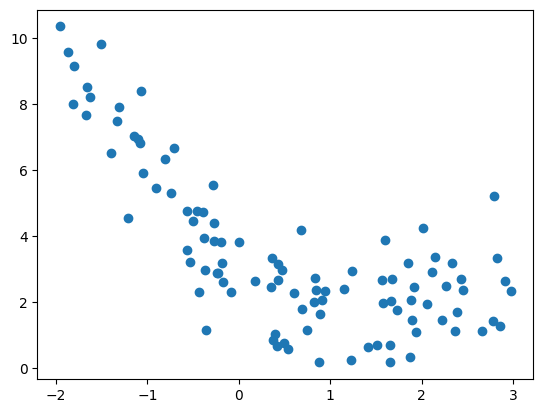

In [36]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

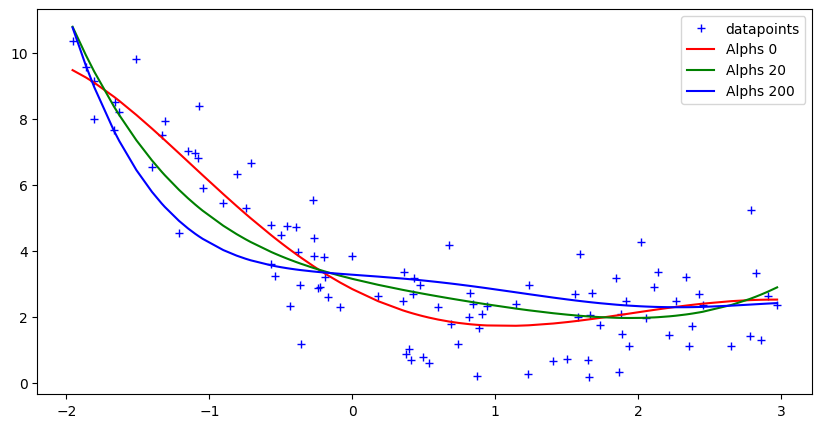

In [50]:
def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=5)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 5))
plt.plot(x1, x2, 'b+', label = "datapoints")

for al, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, al)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = "Alphs {}".format(al))

plt.legend()
plt.show()